In [2]:
import pandas as pd
import glob
import re
import os

In [2]:
files = glob.glob("results/n*_m*_p*_mode*_run*.txt")

# Умножение квадратных матриц

In [3]:
data = []
pattern = r"n(\d+)_m(\d+)_p(\d+)_mode(\d+)_run\d+\.txt"

for filename in files:
    m = re.search(pattern, filename)
    if m:
        n, m_val, p, mode = map(int, m.groups())
        with open(filename, "r") as f:
            content = f.read()
            # Извлекаем необходимые строки
            gpu_clean = float(re.search(r"GPU processing clean time:\s+([\d,\.]+)", content).group(1).replace(',', '.'))
            gpu_total = float(re.search(r"GPU processing total time:\s+([\d,\.]+)", content).group(1).replace(',', '.'))
            cpu_time = float(re.search(r"CPU processing time:\s+([\d,\.]+)", content).group(1).replace(',', '.'))
            data.append({
                "n": n,
                "m": m_val,
                "p": p,
                "mode": mode,
                "gpu_clean": gpu_clean,
                "gpu_total": gpu_total,
                "cpu_time": cpu_time
            })

In [4]:
df = pd.DataFrame(data)

In [5]:
avg_df = df.groupby(["mode", "n", "m", "p"]).mean().reset_index()
avg_df

,mode,n,m,p,gpu_clean,gpu_total,cpu_time
0,0,256,256,256,3.05228,4.19638,59.53750
1,0,512,512,512,3.65012,5.43002,445.89862
2,0,1024,1024,1024,10.05246,13.91570,4282.90126
3,0,2048,2048,2048,59.00440,71.58486,97632.43184
4,1,256,256,256,3.18176,4.24834,60.58374
5,1,512,512,512,3.67040,5.33618,409.88822
6,1,1024,1024,1024,10.15414,14.70932,3963.04210
7,1,2048,2048,2048,61.59758,73.97046,106953.47906
8,2,256,256,256,4.53926,5.57348,60.34986
9,2,512,512,512,15.64812,17.33152,431.11350


In [6]:
for mode in sorted(avg_df["mode"].unique()):
    mode_df = avg_df[avg_df["mode"] == mode]
    # Можно сохранить в CSV или вывести в консоль
    mode_df.to_csv(f"anal_res/performance_mode{mode}.csv", index=False)
    print(f"Режим {mode}")
    print(mode_df[["n", "m", "p", "gpu_clean", "gpu_total", "cpu_time"]])

Режим 0
      n     m     p  gpu_clean  gpu_total     cpu_time
0   256   256   256    3.05228    4.19638     59.53750
1   512   512   512    3.65012    5.43002    445.89862
2  1024  1024  1024   10.05246   13.91570   4282.90126
3  2048  2048  2048   59.00440   71.58486  97632.43184
Режим 1
      n     m     p  gpu_clean  gpu_total      cpu_time
4   256   256   256    3.18176    4.24834      60.58374
5   512   512   512    3.67040    5.33618     409.88822
6  1024  1024  1024   10.15414   14.70932    3963.04210
7  2048  2048  2048   61.59758   73.97046  106953.47906
Режим 2
       n     m     p  gpu_clean  gpu_total      cpu_time
8    256   256   256    4.53926    5.57348      60.34986
9    512   512   512   15.64812   17.33152     431.11350
10  1024  1024  1024  105.56180  109.60708    3971.51486
11  2048  2048  2048  634.02598  646.43630  100271.57158
Режим 3
       n     m     p  gpu_clean  gpu_total     cpu_time
12   256   256   256    4.61366    5.63904     52.71780
13   512   512  

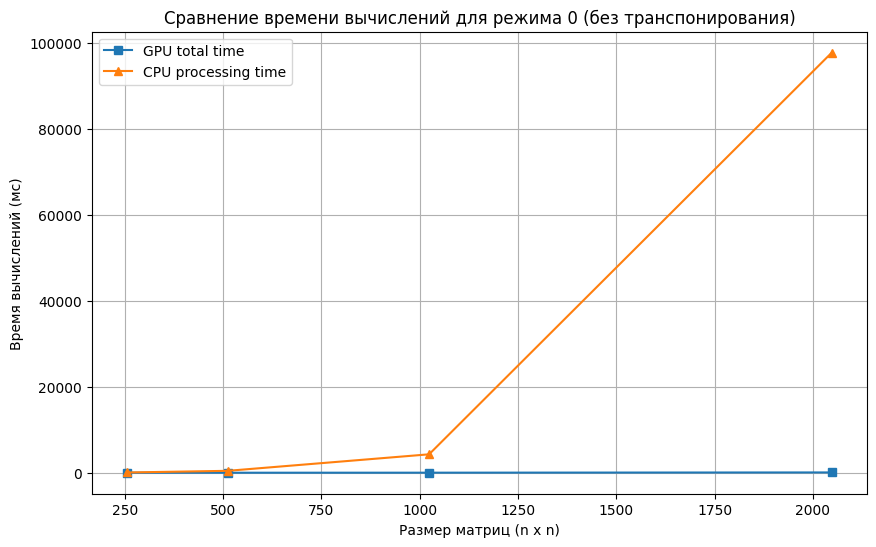

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Читаем данные для нужного режима (например, mode0)
# Если данные разбиты по режимам, можно прочитать соответствующий CSV
df = pd.read_csv("anal_res/performance_mode0.csv")

# Предполагаем, что для квадратных матриц n = m = p, поэтому можно использовать n в качестве размерности.
# Если данные содержат колонки n, m, p, можно, например, взять n.
sizes = df["n"]

# Извлекаем замеры времени
# gpu_clean = df["gpu_clean"]
gpu_total = df["gpu_total"]
cpu_time = df["cpu_time"]

plt.figure(figsize=(10, 6))
# plt.plot(sizes, gpu_clean, marker='o', label='GPU clean time')
plt.plot(sizes, gpu_total, marker='s', label='GPU total time')
plt.plot(sizes, cpu_time, marker='^', label='CPU processing time')
plt.xlabel("Размер матриц (n x n)")
plt.ylabel("Время вычислений (мс)")
plt.title("Сравнение времени вычислений для режима 0 (без транспонирования)")
plt.legend()
plt.grid(True)
plt.show()


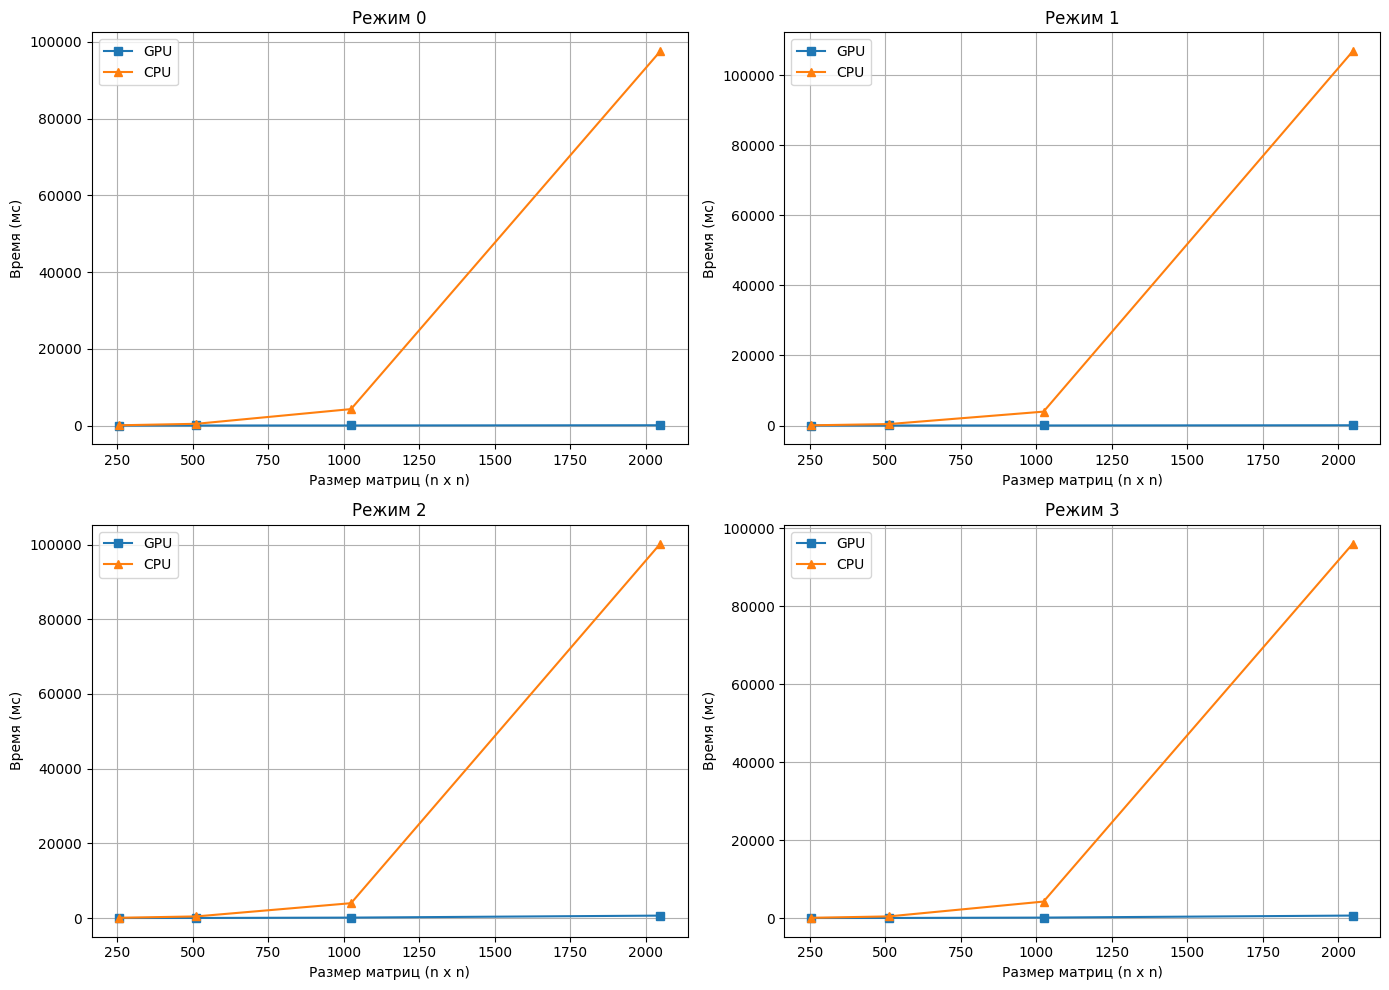

In [8]:

modes = [0, 1, 2, 3]
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

for idx, mode in enumerate(modes):
    df = pd.read_csv(f"anal_res/performance_mode{mode}.csv")
    sizes = df["n"]
    # axs[idx//2, idx%2].plot(sizes, df["gpu_clean"], marker='o', label='GPU clean time')
    axs[idx//2, idx%2].plot(sizes, df["gpu_total"], marker='s', label='GPU')
    axs[idx//2, idx%2].plot(sizes, df["cpu_time"], marker='^', label='CPU')
    axs[idx//2, idx%2].set_xlabel("Размер матриц (n x n)")
    axs[idx//2, idx%2].set_ylabel("Время (мс)")
    axs[idx//2, idx%2].set_title(f"Режим {mode}")
    axs[idx//2, idx%2].legend()
    axs[idx//2, idx%2].grid(True)

plt.tight_layout()
plt.show()


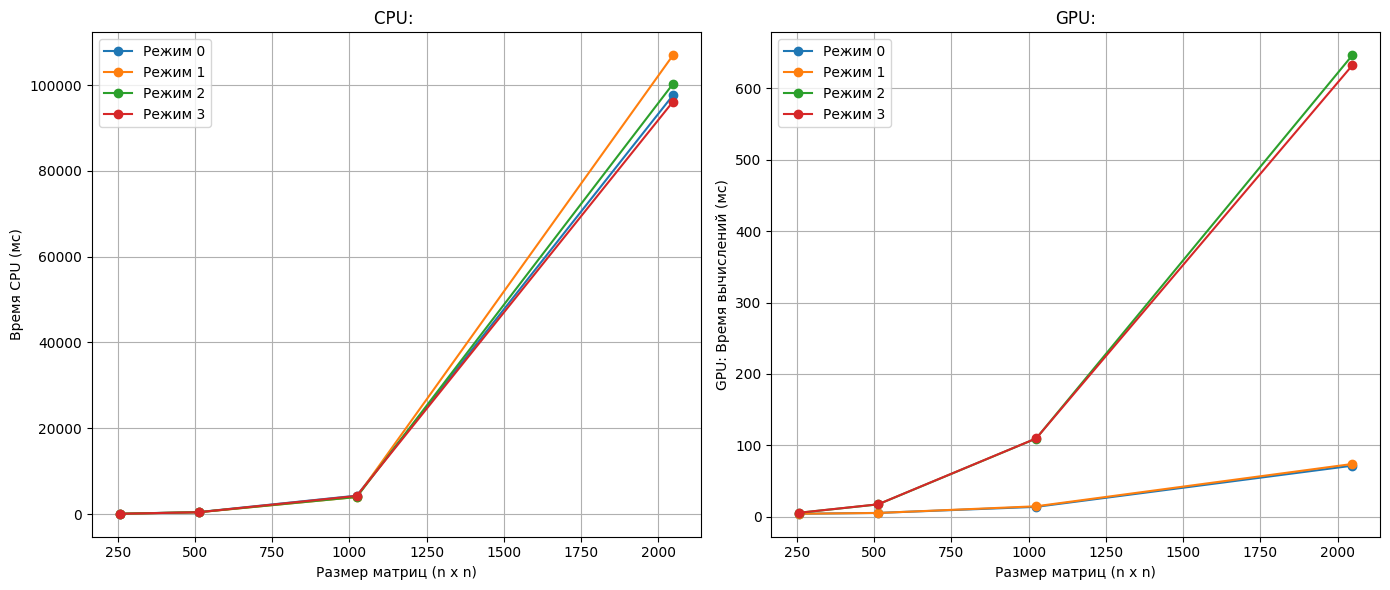

In [9]:
# Режимы размещения матриц: 0, 1, 2, 3
modes = [0, 1, 2, 3]

# Для каждого режима предполагается CSV-файл с именем вида "performance_mode{mode}.csv"
# CSV должен содержать как минимум столбцы: n, cpu_time, gpu_clean, gpu_total (где n - размерность квадратных матриц)

plt.figure(figsize=(14, 6))

# График для CPU
plt.subplot(1, 2, 1)
for mode in modes:
    df = pd.read_csv(f"anal_res/performance_mode{mode}.csv")
    plt.plot(df["n"], df["cpu_time"], marker='o', label=f'Режим {mode}')
plt.xlabel("Размер матриц (n x n)")
plt.ylabel("Время CPU (мс)")
plt.title("CPU: ")
plt.legend()
plt.grid(True)

# График для GPU (используем чистое время работы ядра, например gpu_clean)
plt.subplot(1, 2, 2)
for mode in modes:
    df = pd.read_csv(f"anal_res/performance_mode{mode}.csv")
    plt.plot(df["n"], df["gpu_total"], marker='o', label=f'Режим {mode}')
plt.xlabel("Размер матриц (n x n)")
plt.ylabel("GPU: Время вычислений (мс)")
plt.title("GPU:")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Умножение матриц N x M и M x P

In [4]:
INPUT_DIR = "results_1"
OUTPUT_DIR = "anal_res_1"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [5]:
pattern = r"n(\d+)_m(\d+)_p(\d+)_mode(\d+)_run\d+\.txt"

records = []
for path in glob.glob(os.path.join(INPUT_DIR, "*.txt")):
    fname = os.path.basename(path)
    m = re.match(pattern, fname)
    if not m:
        continue
    n, m_val, p, mode = map(int, m.groups())
    text = open(path, encoding="utf-8").read()
    # Парсим времена (замена запятой на точку)
    gpu_clean = float(re.search(r"GPU processing clean time:\s*([\d,\.]+)", text).group(1).replace(',', '.'))
    gpu_total = float(re.search(r"GPU processing total time:\s*([\d,\.]+)", text).group(1).replace(',', '.'))
    cpu_time = float(re.search(r"CPU processing time:\s*([\d,\.]+)", text).group(1).replace(',', '.'))
    records.append((mode, n, m_val, p, gpu_clean, gpu_total, cpu_time))

In [6]:
df = pd.DataFrame(records, columns=["mode","n","m","p","gpu_clean","gpu_total","cpu_time"])
grouped = df.groupby(["mode","n","m","p"], as_index=False).mean()
grouped

,mode,n,m,p,gpu_clean,gpu_total,cpu_time
0,0,256,128,64,2.65962,3.41818,7.06678
1,0,512,256,128,3.08252,4.33122,57.78670
2,0,1024,512,256,3.63364,5.60830,440.69442
3,0,2048,1024,512,9.98032,14.32870,4499.44364
4,1,256,128,64,2.63358,3.38178,6.93906
5,1,512,256,128,2.99176,4.09626,58.69132
6,1,1024,512,256,3.59046,5.49092,472.88774
7,1,2048,1024,512,10.02920,14.37440,4506.28430
8,2,256,128,64,2.84630,3.67780,7.56318
9,2,512,256,128,4.58708,5.72422,59.27936


In [8]:
for mode in sorted(grouped["mode"].unique()):
    df_mode = grouped[grouped["mode"] == mode].sort_values(by=["n","m","p"])
    df_mode.to_csv(os.path.join(OUTPUT_DIR, f"mode{mode}_performance.csv"), index=False)
    print(f"Режим {mode}")
    print(df_mode[["n", "m", "p", "gpu_clean", "gpu_total", "cpu_time"]])

Режим 0
      n     m    p  gpu_clean  gpu_total    cpu_time
0   256   128   64    2.65962    3.41818     7.06678
1   512   256  128    3.08252    4.33122    57.78670
2  1024   512  256    3.63364    5.60830   440.69442
3  2048  1024  512    9.98032   14.32870  4499.44364
Режим 1
      n     m    p  gpu_clean  gpu_total    cpu_time
4   256   128   64    2.63358    3.38178     6.93906
5   512   256  128    2.99176    4.09626    58.69132
6  1024   512  256    3.59046    5.49092   472.88774
7  2048  1024  512   10.02920   14.37440  4506.28430
Режим 2
       n     m    p  gpu_clean  gpu_total    cpu_time
8    256   128   64    2.84630    3.67780     7.56318
9    512   256  128    4.58708    5.72422    59.27936
10  1024   512  256   15.97206   17.82796   489.11070
11  2048  1024  512  105.93972  110.49152  4700.15380
Режим 3
       n     m    p  gpu_clean  gpu_total    cpu_time
12   256   128   64    2.84144    3.67158     6.83958
13   512   256  128    4.63794    5.80970    57.91774
14  10

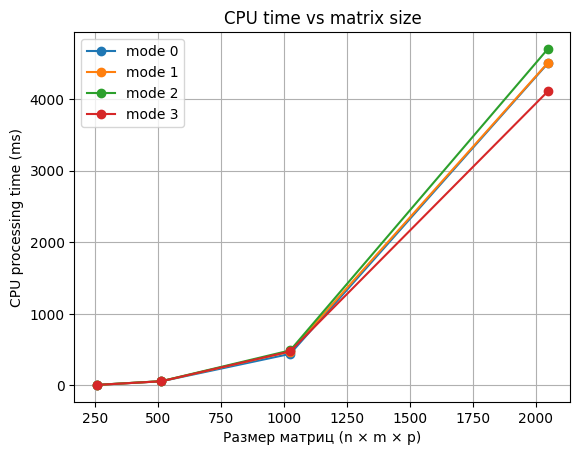

In [14]:
plt.figure()
for mode in sorted(grouped["mode"].unique()):
    tmp = grouped[grouped["mode"] == mode]
    plt.plot(tmp["n"], tmp["cpu_time"], marker="o", label=f"mode {mode}")
plt.xlabel("Размер матриц (n × m × p)")
plt.ylabel("CPU processing time (ms)")
plt.title("CPU time vs matrix size")
plt.legend()
plt.grid(True)
plt.show()
# plt.savefig(os.path.join(OUTPUT_DIR, "cpu_time_comparison.png"))
# plt.close()

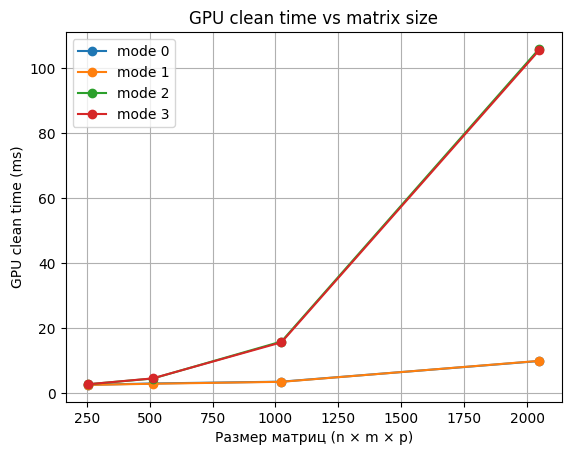

In [15]:
plt.figure()
for mode in sorted(grouped["mode"].unique()):
    tmp = grouped[grouped["mode"] == mode]
    plt.plot(tmp["n"], tmp["gpu_clean"], marker="o", label=f"mode {mode}")
plt.xlabel("Размер матриц (n × m × p)")
plt.ylabel("GPU clean time (ms)")
plt.title("GPU clean time vs matrix size")
plt.legend()
plt.grid(True)
plt.show()
# plt.savefig(os.path.join(OUTPUT_DIR, "gpu_time_comparison.png"))
# plt.close()

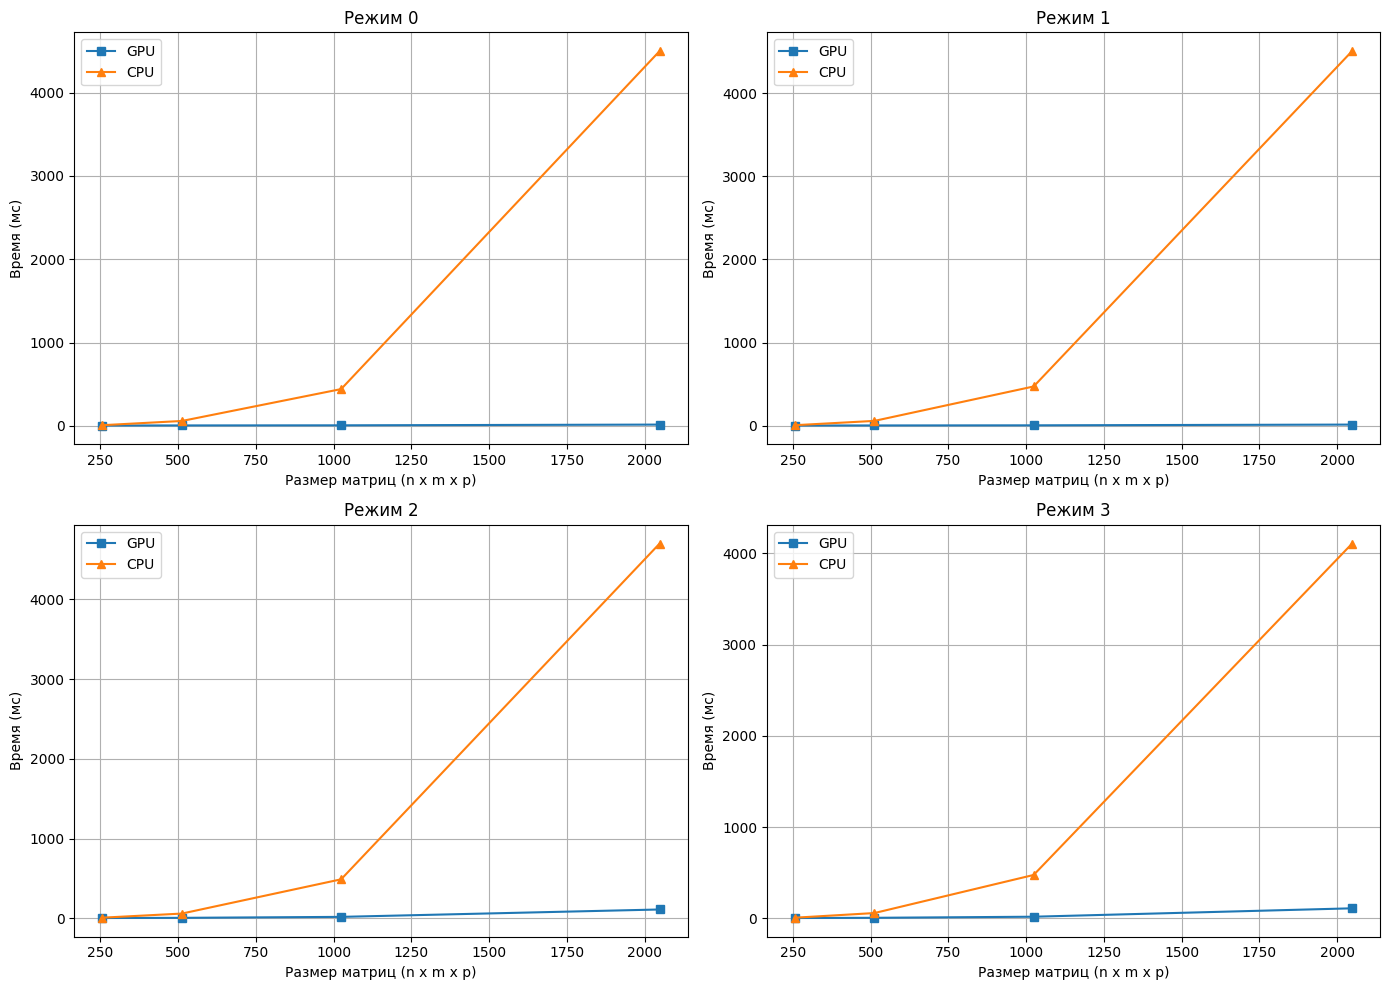

In [16]:
INPUT_DIR = "anal_res_1"
OUTPUT_DIR = INPUT_DIR  # сохраняем туда же
modes = [0, 1, 2, 3]

fig, axs = plt.subplots(2, 2, figsize=(14, 10))
for idx, mode in enumerate(modes):
    path = os.path.join(INPUT_DIR, f"mode{mode}_performance.csv")
    df = pd.read_csv(path)
    
    sizes = df["n"]
    # axs[idx//2, idx%2].plot(sizes, df["gpu_clean"], marker='o', label='GPU clean time')
    axs[idx//2, idx%2].plot(sizes, df["gpu_total"], marker='s', label='GPU')
    axs[idx//2, idx%2].plot(sizes, df["cpu_time"], marker='^', label='CPU')
    axs[idx//2, idx%2].set_xlabel("Размер матриц (n x m x p)")
    axs[idx//2, idx%2].set_ylabel("Время (мс)")
    axs[idx//2, idx%2].set_title(f"Режим {mode}")
    axs[idx//2, idx%2].legend()
    axs[idx//2, idx%2].grid(True)

plt.tight_layout()
plt.show()
    # outfile = os.path.join(OUTPUT_DIR, f"mode{mode}_cpu_vs_gpu.png")
    # plt.savefig(outfile)
    # plt.close()
    # print(f"График сохранён: {outfile}")

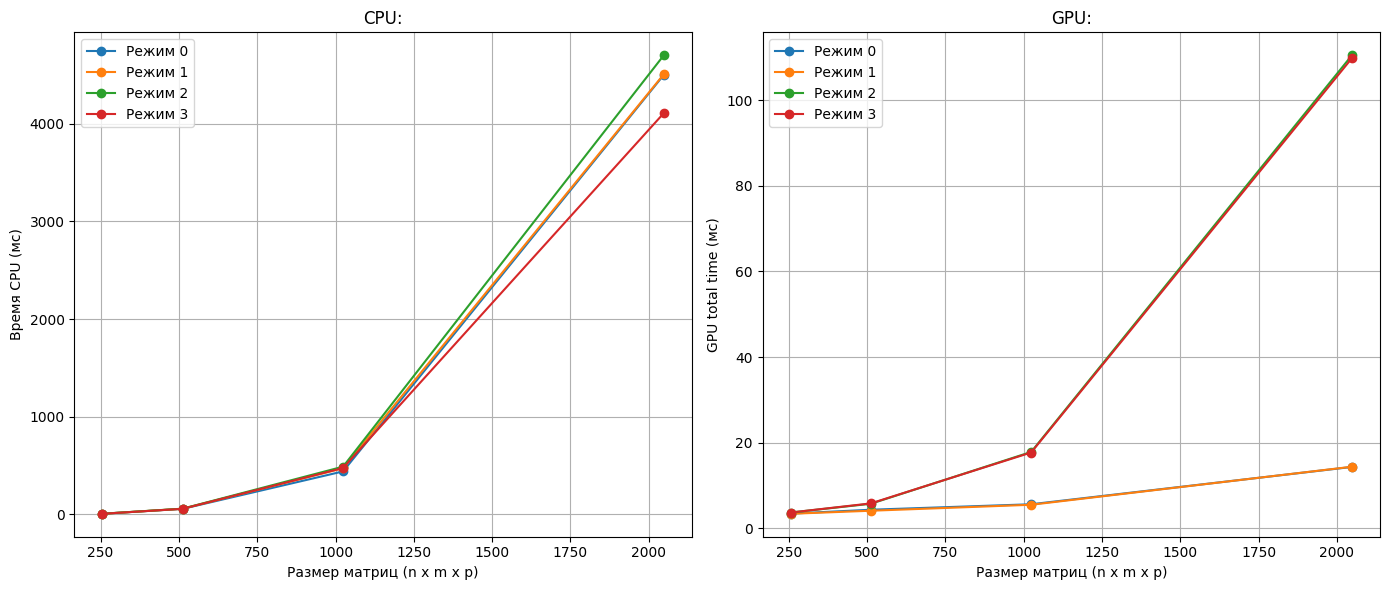

In [17]:
# Режимы размещения матриц: 0, 1, 2, 3
modes = [0, 1, 2, 3]

# Для каждого режима предполагается CSV-файл с именем вида "performance_mode{mode}.csv"
# CSV должен содержать как минимум столбцы: n, cpu_time, gpu_clean, gpu_total (где n - размерность квадратных матриц)

plt.figure(figsize=(14, 6))

# График для CPU
plt.subplot(1, 2, 1)
for mode in modes:
    df = pd.read_csv(f"anal_res_1/mode{mode}_performance.csv")
    plt.plot(df["n"], df["cpu_time"], marker='o', label=f'Режим {mode}')
plt.xlabel("Размер матриц (n x m x p)")
plt.ylabel("Время CPU (мс)")
plt.title("CPU:")
plt.legend()
plt.grid(True)

# График для GPU (используем чистое время работы ядра, например gpu_clean)
plt.subplot(1, 2, 2)
for mode in modes:
    df = pd.read_csv(f"anal_res_1/mode{mode}_performance.csv")
    plt.plot(df["n"], df["gpu_total"], marker='o', label=f'Режим {mode}')
plt.xlabel("Размер матриц (n x m x p)")
plt.ylabel("GPU total time (мс)")
plt.title("GPU:")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()